<a href="https://colab.research.google.com/github/marinhotechdev-ia/InteligenciaArtificial/blob/main/analise_credito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Crédito
## 1. EDA

,renda_mensal,score_credito,dividas_ativas,emprestimo_aprovado
0,5493.43,480,4,0
1,4223.47,600,5,0
2,5795.38,609,5,1
3,7546.06,554,1,1
4,4031.69,631,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   renda_mensal         100 non-null    float64
 1   score_credito        100 non-null    int64  
 2   dividas_ativas       100 non-null    int64  
 3   emprestimo_aprovado  100 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


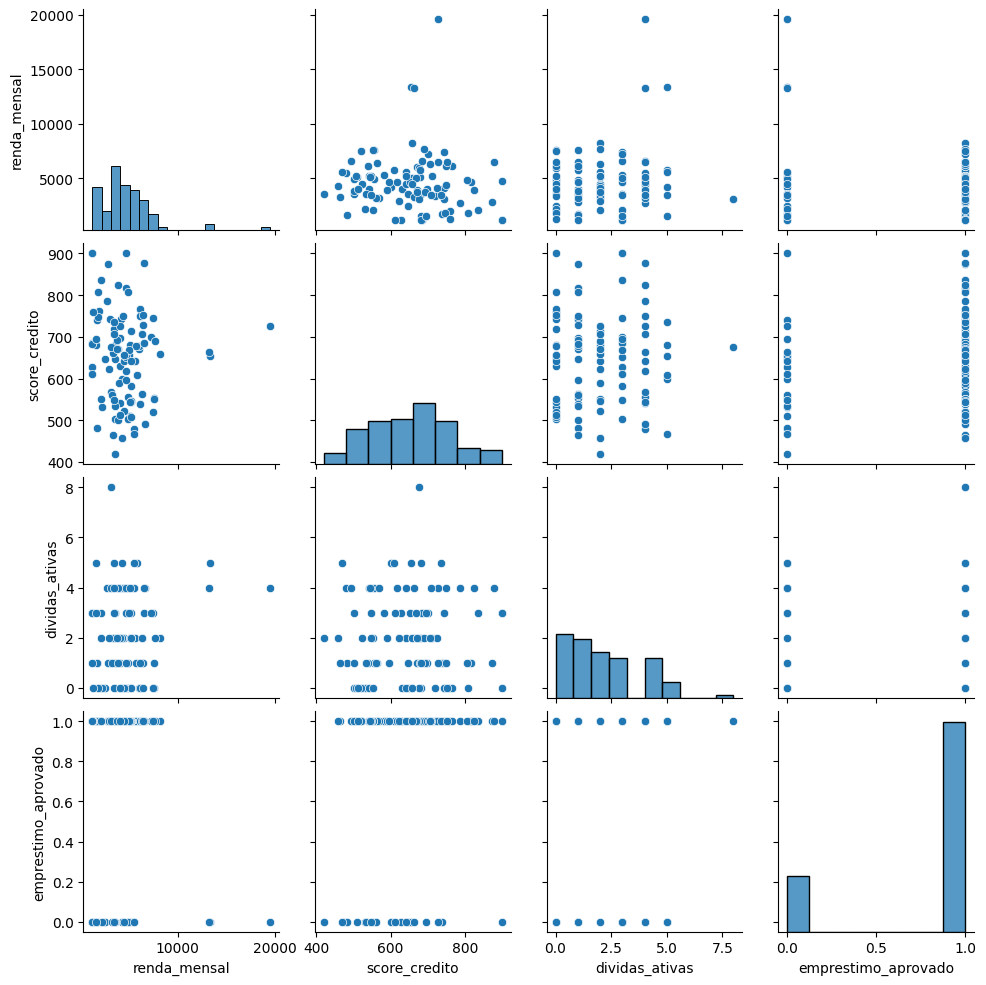

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# dataset_emprestimo_aprovacao.csv
df = pd.read_csv('dataset_emprestimo_aprovacao.csv')
display(df.head())
df.info()
sns.pairplot(df)
plt.show()

## 2. Split (Train/Test)

In [7]:
# Ajuste o nome da coluna alvo conforme o dataset real (ex: 'aprovado')
X = df.drop('emprestimo_aprovado', axis=1)
y = df['emprestimo_aprovado']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Treinamento

In [8]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## 4. Métricas

In [9]:
y_pred = modelo.predict(X_test)
print('Matriz de Confusão:\n', confusion_matrix(y_test, y_pred))
print('Acurácia:', accuracy_score(y_test, y_pred))
print('Precisão:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))

Matriz de Confusão:
 [[ 0  3]
 [ 0 17]]
Acurácia: 0.85
Precisão: 0.85
Recall: 1.0


## 5. Interpretação

In [10]:
print('Coeficientes:', modelo.coef_)
print('Intercepto:', modelo.intercept_)
"""
Explicação Matemática:
A regressão logística modela a probabilidade de aprovação (p) pela função sigmoide:
p = 1 / (1 + e^-(β0 + β1*X1 + ... + βn*Xn))
- Intercepto (β0): Representa o log-odds quando todas as variáveis independentes são iguais a 0.
- Coeficientes (βi): Cada coeficiente indica a mudança no log-odds da variável alvo (aprovação) para um aumento de uma unidade na variável correspondente, mantendo as demais constantes.
"""

Coeficientes: [[ 3.64235563e-05  4.62240970e-03 -2.28236080e-01]]
Intercepto: [-1.38694931]


'\nExplicação Matemática:\nA regressão logística modela a probabilidade de aprovação (p) pela função sigmoide:\np = 1 / (1 + e^-(β0 + β1*X1 + ... + βn*Xn))\n- Intercepto (β0): Representa o log-odds quando todas as variáveis independentes são iguais a 0.\n- Coeficientes (βi): Cada coeficiente indica a mudança no log-odds da variável alvo (aprovação) para um aumento de uma unidade na variável correspondente, mantendo as demais constantes.\n'